In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path 
import numpy as np
from tabulate import tabulate

# dir = Path(r"C:/Users/nadia/Documents/")
name = "DST_BIL54.csv"
df = pd.read_csv(name)

In [8]:
# "Total" angives i millioner 
df["total"] = df["total"]/(10**6)
# Object to datetime 
df["time"] = pd.to_datetime(df["time"])

# Creating a "year" column with decimal values for months
df["year"] = df["time"].dt.year + (df["time"].dt.month - 1) / 12

Vi koncenterer os herfra om variablerne "total" og "year":

* y:  total car registrations
* x:  datetime, year and month 

In [9]:
x = df["year"]
y = df["total"]
x.shape, y.shape

((84,), (84,))

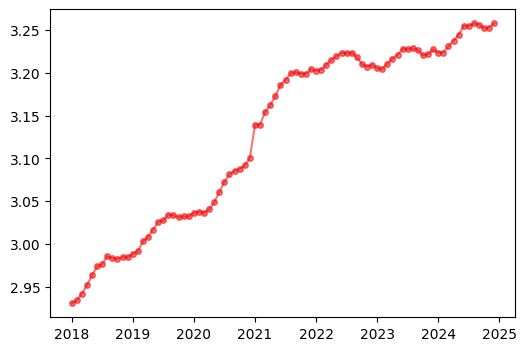

In [10]:
# Raw data plot
plt.figure(figsize=(6,4))
plt.plot(x, y, marker="o", linestyle="-", color="lightgrey", alpha = 0.4, markersize = 4)
plt.plot(x, y, marker="o", linestyle="-", color="red", alpha = 0.5, markersize = 4)

In [11]:
# Partition in test and train 
cut = "2024-01-01"
cut = pd.to_datetime(cut)

df_train = df[df["time"] < cut]
df_test  = df[df["time"] >= cut]

x_train = df_train["year"]
y_train = df_train["total"]
x_test = df_test["year"]
y_test = df_test["total"]

In [12]:
x_train.shape, y_train.shape, x_test.shape, y_test.shape

((72,), (72,), (12,), (12,))

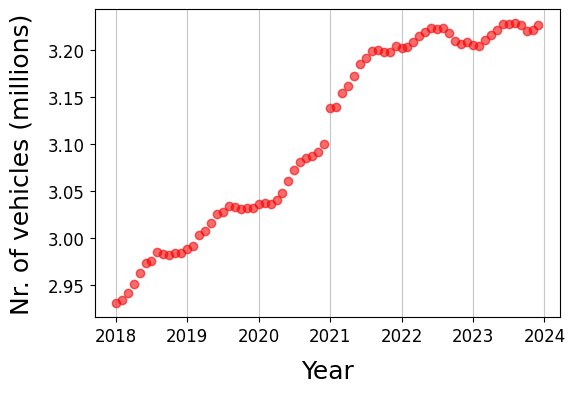

In [13]:
# Plot of train data
plt.figure(figsize=(6,4))
plt.plot(x_train, y_train, marker="o", linestyle="", label="Train", color = "lightgrey", alpha = 0.4)
plt.plot(x_train, y_train, marker="o", linestyle="", label="Train", color = "red", alpha = 0.55)
plt.grid(axis = "x", alpha = 0.7)
plt.xlabel("Year", fontsize = 18, labelpad=10)
plt.ylabel("Nr. of vehicles (millions)", fontsize = 18, labelpad=10)
plt.xticks(fontsize = 12)
plt.yticks(fontsize = 12)
plt.show()

### Models

GLM: $Y_t = \theta_1 + \theta_2 \cdot x_t + \epsilon_t $

In [14]:
# Design matrix for training data
A = np.column_stack([np.ones(len(x_train)), x_train])

In [15]:
# Secure stability
print("Determinant:",np.linalg.det(A.T @ A))
print("Rang: ", np.linalg.matrix_rank(A))

# Method 1: Normal equations
c = np.linalg.solve(A.T@A, A.T@y_train)
print("Coefficients: ", c)

Determinant: 15549.000004242993
Rang:  2
Coefficients:  [-1.10355428e+02  5.61445562e-02]


In [16]:
# These are just precautions to test the different methods - but gives same result
# Method 2: Least squares
c1 = np.linalg.lstsq(A, y_train, rcond=None)[0]   # mest stabilt
# Method 3: Pseudoinverse
c2 = np.linalg.pinv(A) @ y_train                  # bruger Moore–Penrose pseudoinvers
c1, c2

(array([-1.10355428e+02,  5.61445562e-02]),
 array([-1.10355428e+02,  5.61445562e-02]))

In [17]:
# Predicitions: test and train
y_pred = c[0] + c[1] * x_test
y_train_pred = c[0] + c[1] * x_train

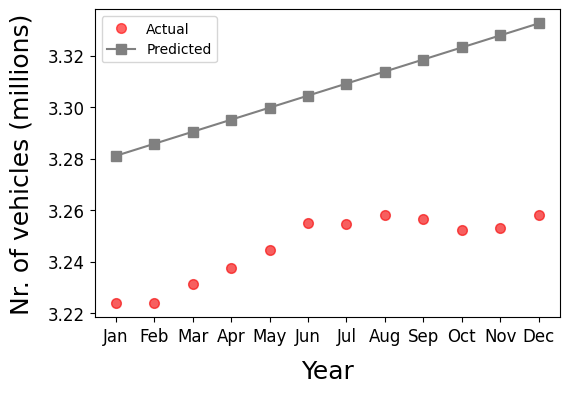

In [18]:
x_ind = np.arange(len(y_test)) # 0,1,2,...,11
plt.figure(figsize=(6,4))
plt.plot(x_ind, y_test, marker="o", linestyle="", color = "lightgrey", alpha = 0.4, markersize = 7)
plt.plot(x_ind, y_test, marker="o", linestyle="", color = "red", alpha = 0.6, label="Actual", markersize = 7)
plt.plot(x_ind, y_pred, label="Predicted", marker="s", linestyle="-", color = "grey", markersize = 7)
plt.xlabel("Year", fontsize = 18, labelpad=10)
plt.ylabel("Nr. of vehicles (millions)", fontsize = 18, labelpad=10)
plt.xticks(
    ticks = range(len(y_test)),
    labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
              "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"],
    fontsize = 12)
plt.yticks(fontsize = 12)

plt.legend()
plt.show()


Text(0, 0.5, 'Nr. of vehicles (millions)')

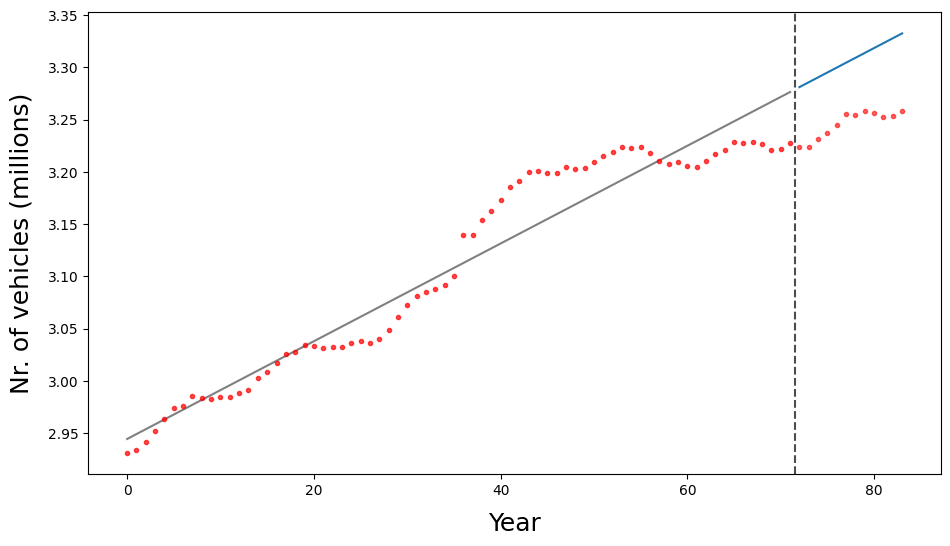

In [19]:
x_ind = np.arange(len(y_test) + len(y_train)) # 0,1,2,...,11

plt.figure(figsize=(11,6))

plt.plot(x_ind[:len(y_train)], y_train_pred, color = "grey", marker = "", ls = "-", markersize = 3)
plt.plot(x_ind[:len(y_train)], y_train, marker = ".", ls = " ", color = "red", alpha = 0.7)
plt.axvline(x = len(y_train) - 0.5, color = "black", ls = "--", alpha = 0.7)

plt.plot(x_ind[len(y_train):], y_pred, color = "tab:blue")
plt.plot(x_ind[len(y_train):], y_test, marker = ".", ls = " ", color = "red", alpha = 0.6)
plt.xlabel("Year", fontsize = 18, labelpad=10)
plt.ylabel("Nr. of vehicles (millions)", fontsize = 18, labelpad=10)


Text(0, 0.5, 'Nr. of vehicles (millions)')

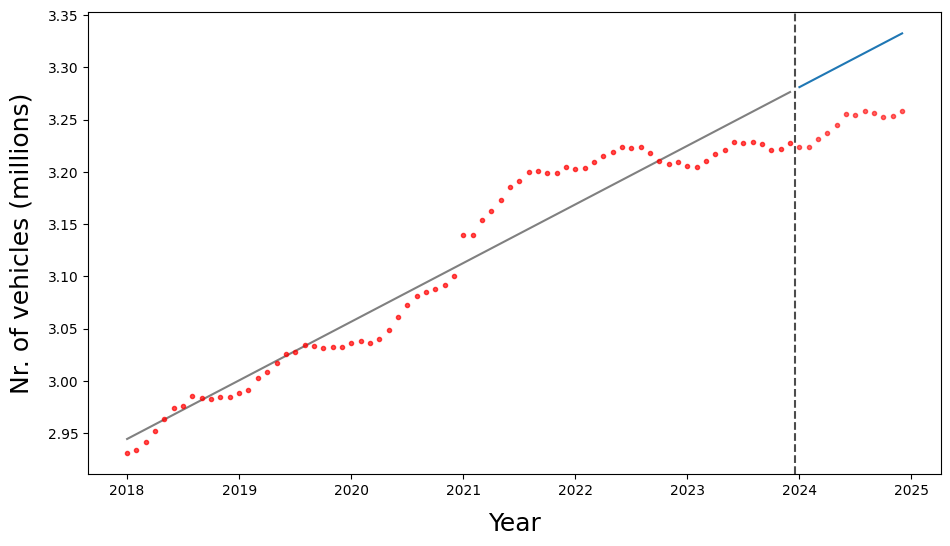

In [20]:
x_ind = np.arange(len(y_test) + len(y_train)) # 0,1,2,...,11

plt.figure(figsize=(11,6))

plt.plot(df["year"][:len(y_train)], y_train_pred, color = "grey", marker = "", ls = "-", markersize = 3)
plt.plot(df["year"][:len(y_train)], y_train, marker = ".", ls = " ", color = "red", alpha = 0.7)

plt.plot(df["year"][len(y_train):], y_pred, color = "tab:blue")
plt.plot(df["year"][len(y_train):], y_test, marker = ".", ls = " ", color = "red", alpha = 0.6)
plt.axvline(x = df["year"][len(y_train) - 1] + (df["year"][len(y_train)] - df["year"][len(y_train) - 1])/2, color = "black", ls = "--", alpha = 0.7)

plt.xlabel("Year", fontsize = 18, labelpad=10)
plt.ylabel("Nr. of vehicles (millions)", fontsize = 18, labelpad=10)


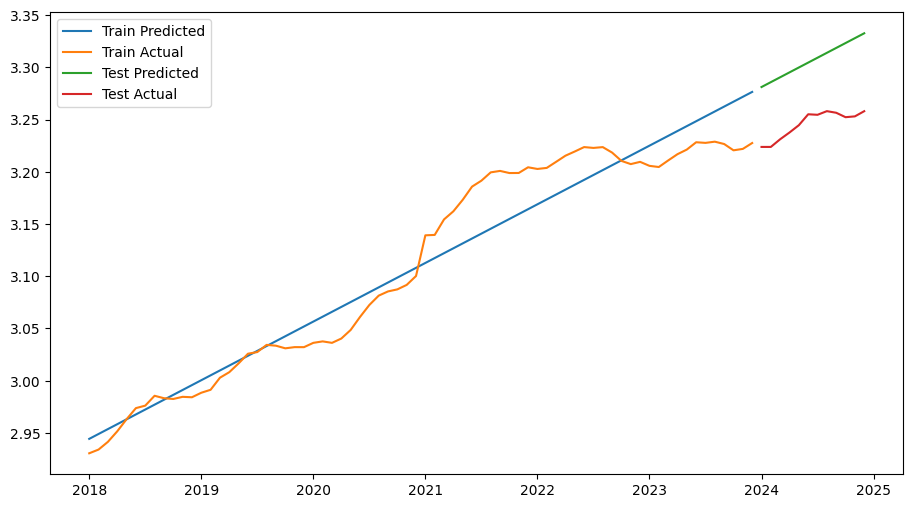

In [21]:
x_ind = np.arange(len(y_test) + len(y_train)) # 0,1,2,...,11

plt.figure(figsize=(11,6))

plt.plot(df["year"][:len(y_train)], y_train_pred)
plt.plot(df["year"][:len(y_train)], y_train)

plt.plot(df["year"][len(y_train):], y_pred)
plt.plot(df["year"][len(y_train):], y_test)
plt.legend(["Train Predicted", "Train Actual", "Test Predicted", "Test Actual"])


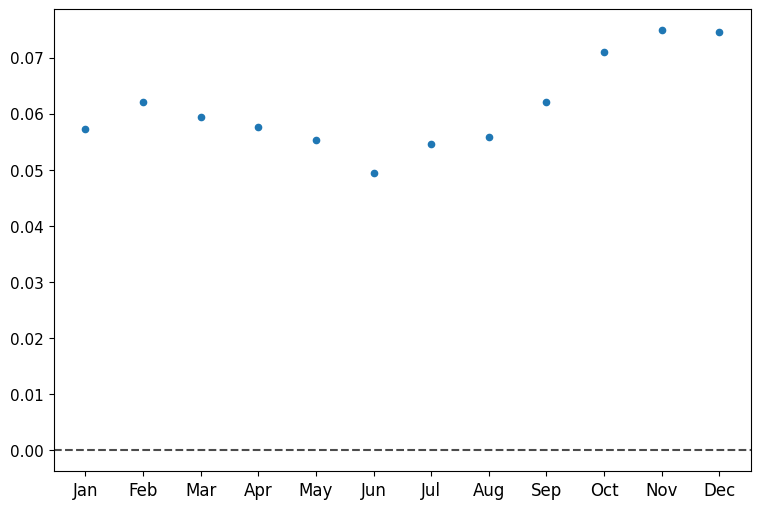

In [22]:
res = y_pred-y_test

months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
          "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
plt.figure(figsize=(9,6))
plt.plot(range(len(res)), res, '.', markersize = 9)
plt.xticks(range(len(res)), months, fontsize=12)
plt.axhline(0, color="black", ls="--", alpha=0.7)
plt.yticks(fontsize=11)
plt.show()



In [ ]:
# Calculate residuals from training data
residuals_train = y_train - y_train_pred

residuals_test = y_test - y_pred

# Create diagnostic plots
fig, axes = plt.subplots(2, figsize=(14, 10))

In [ ]:
plt.figure(figsize=(11,6))
plt.plot(x_train[5:], pred_error_07, label='Prediction Error', linestyle='-', marker='o', color='grey')
plt.axhline(y=np.mean(pred_error_07), color='red', linestyle='--', linewidth=1,alpha=0.7, label=f'Mean = {np.mean(pred_error_07):.4f}')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Prediction error', fontsize=12)
plt.title(f'One-step prediction errors for λ = 0.7', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

## 4: WLS

In [76]:

df_train.head

<bound method NDFrame.head of          time     total  gasoline   diesel  fgas  ngas  electricity  \
0  2018-01-01  2.930483   1781826  1136656    12   256         9304   
1  2018-02-01  2.934044   1783338  1138414    12   255         9343   
2  2018-03-01  2.941422   1787219  1141576    12   257         9399   
3  2018-04-01  2.951498   1793554  1144846    12   257         9548   
4  2018-05-01  2.963093   1799795  1149840    12   256         9665   
..        ...       ...       ...      ...   ...   ...          ...   
67 2023-08-01  3.228835   1851651  1091900    16   552       166046   
68 2023-09-01  3.226588   1845911  1084498    16   550       175592   
69 2023-10-01  3.220559   1838787  1075629    16   533       184125   
70 2023-11-01  3.221920   1835019  1068514    16   533       194948   
71 2023-12-01  3.227541   1831941  1062385    16   533       207888   

    petroleum  hydrogen  methanol  ethanol  pluginhybrid  otherfuels  \
0           0        81         0        0   

In [77]:
N = len(x_train)
time_t = np.arange(0,N)

#4.1 find covariance variance matrix 
lambda_init = 0.9

lambda_weights = lambda_init ** np.arange(N-1, -1, -1)
cov_var_matrix_WLS = np.diag(1/lambda_weights)  #(3.98) in TSA book
cov_var_matrix_OLS = np.identity(N) #3.2.1.3 Unweighted LS estimates (TSA book)

print(cov_var_matrix_WLS[60][60])
print(cov_var_matrix_OLS[60][60])

3.186635545324934
1.0


Text(0, 0.5, 'weight (lambda)')

Text(0, 0.5, 'weight (lambda)')

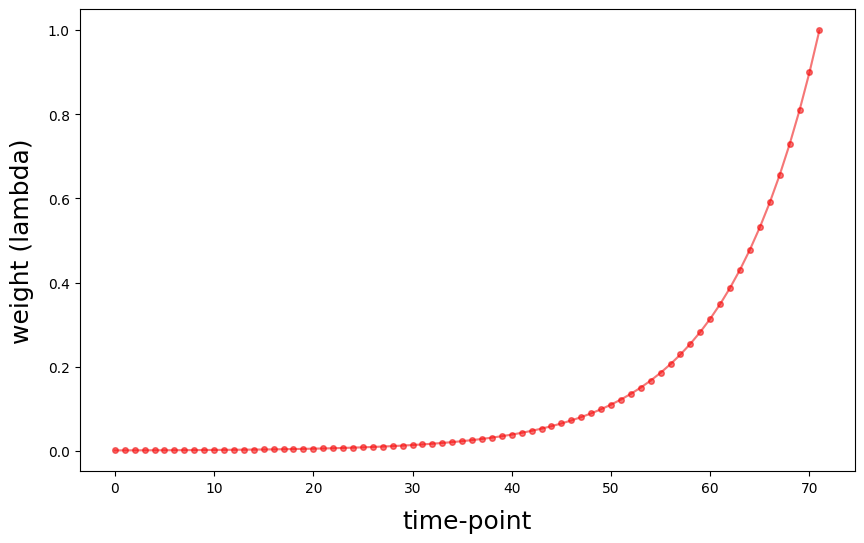

In [78]:

#4.2 plot weights as a function of timepoints for 

plt.figure(figsize=(10,6))
plt.plot(time_t, lambda_weights, marker="o", linestyle="-", color="lightgrey", alpha = 0.4, markersize = 4)
plt.plot(time_t, lambda_weights, marker="o", linestyle="-", color="red", alpha = 0.5, markersize = 4)
plt.xlabel("time-point", fontsize = 18, labelpad=10)
plt.ylabel("weight (lambda)", fontsize = 18, labelpad=10)

In [79]:

# 4.3 sum weights (lambda) and OLS
print("sum of WLS weights", lambda_weights.sum())

print("\nsum of OLS weights", N)

sum of WLS weights 9.994924712139436

sum of OLS weights 72


In [80]:
#4.4 estimate unknown params with weigts
    #eq (3.99)in TSA book
xtrains= np.column_stack([np.ones(len(x_train)), x_train])
ytrains= y_train.to_numpy().reshape(-1, 1)   

cov_var_matrix_WLS_reciprocal = np.diag(lambda_weights)

F_N_WLS = xtrains.T @ cov_var_matrix_WLS_reciprocal @ xtrains

h_N_WLS =  xtrains.T @  cov_var_matrix_WLS_reciprocal @ ytrains

thetas = np.linalg.inv(F_N_WLS) @  h_N_WLS

print("theta 1 (intercept): ", thetas[0],"\ntheta 2 (slope): ", thetas[1])

theta 1 (intercept):  [-52.48286172] 
theta 2 (slope):  [0.0275299]


In [81]:

thetas[0] + thetas[1] * x_test

72    3.237659
73    3.239953
74    3.242247
75    3.244541
76    3.246836
77    3.249130
78    3.251424
79    3.253718
80    3.256012
81    3.258306
82    3.260601
83    3.262895
Name: year, dtype: float64

In [82]:
xtrains= np.column_stack([np.ones(len(x_train)), x_train])
ytrains= y_train.to_numpy().reshape(-1, 1)   

def predict_12_WLS(lambda_init_value):
    lambda_weights = lambda_init_value ** np.arange(N-1, -1, -1)
    cov_var_matrix_WLS_reciprocal = np.diag(lambda_weights)
    F_N_WLS = xtrains.T @ cov_var_matrix_WLS_reciprocal @ xtrains
    h_N_WLS =  xtrains.T @  cov_var_matrix_WLS_reciprocal @ ytrains
    thetas = np.linalg.inv(F_N_WLS) @  h_N_WLS

    print("lambda ", lambda_init_value,"\ntheta 1 (intercept): ", thetas[0],"theta 2 (slope): ", thetas[1])


#HAve function return as list so it can be plotted later
    return thetas[0] + thetas[1] * x_test

In [83]:
#4.5 predict 12 time-steps ahead
predict_12_WLS(0.9)

lambda  0.9 
theta 1 (intercept):  [-52.48286172] theta 2 (slope):  [0.0275299]


lambda  0.9 
theta 1 (intercept):  [-52.48286172] theta 2 (slope):  [0.0275299]


72    3.237659
73    3.239953
74    3.242247
75    3.244541
76    3.246836
77    3.249130
78    3.251424
79    3.253718
80    3.256012
81    3.258306
82    3.260601
83    3.262895
Name: year, dtype: float64

In [84]:

#4.6 repeat for λ = 0.99, λ = 0.8, λ = 0.7 and λ = 0.6.
lambda_initialization_list = [0.99, 0.8, 0.7, 0.6]
boxto = []
for inits in lambda_initialization_list:
    boxto.append(predict_12_WLS(inits))

print(boxto)

lambda  0.99 
theta 1 (intercept):  [-107.09818742] theta 2 (slope):  [0.05453297]
lambda  0.8 
theta 1 (intercept):  [-21.52797312] theta 2 (slope):  [0.01223115]
lambda  0.7 
theta 1 (intercept):  [-15.73997849] theta 2 (slope):  [0.00937098]
lambda  0.6 
theta 1 (intercept):  [-11.32407116] theta 2 (slope):  [0.00718895]
[72    3.276551
73    3.281096
74    3.285640
75    3.290185
76    3.294729
77    3.299274
78    3.303818
79    3.308362
80    3.312907
81    3.317451
82    3.321996
83    3.326540
Name: year, dtype: float64, 72    3.227869
73    3.228888
74    3.229907
75    3.230926
76    3.231946
77    3.232965
78    3.233984
79    3.235003
80    3.236023
81    3.237042
82    3.238061
83    3.239080
Name: year, dtype: float64, 72    3.226889
73    3.227670
74    3.228451
75    3.229232
76    3.230013
77    3.230793
78    3.231574
79    3.232355
80    3.233136
81    3.233917
82    3.234698
83    3.235479
Name: year, dtype: float64, 72    3.226355
73    3.226954
74    3.227554
75  

## 5: recursive estimation and optimization

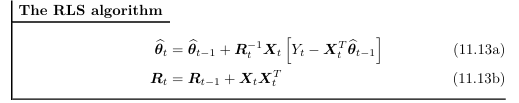

### Opg 5.2

In [23]:
x = [2018, 2018.083]
y = [29.3, 29.3]
R0 = np.array(([0.1, 0],[0, 0.1]))
theta0 = np.array([0, 0])
t = 3



def update(t, theta, R, x, y ):
    R_cal = []
    theta_cal = []

    

    for i in range(1, t+1):
            R_cal.append(R + x[i] @ x[i].T)
            theta + np.linalg.inv(R_cal) @ x[i] * (y[i] - x[i].T @ np.linalg(theta_cal))
            theta_cal.append()


In [24]:
x = np.array(([1,1],[2018, 2018.083]))
print(x)
x[:,0]

[[1.000000e+00 1.000000e+00]
 [2.018000e+03 2.018083e+03]]


array([1.000e+00, 2.018e+03])

In [25]:
x = np.array(([1,1,1],[2018, 2018.083, 2018.167]))
y = [29.3, 29.3, 29.4]

R0 = np.array(([0.1, 0],[0, 0.1]))
theta0 = np.array([0, 0])
t = 3

R_cal = []
theta_cal = []

In [26]:
R_cal.append(R0 + np.outer(x[:,0], x[:,0]))
theta_cal.append(theta0 + np.linalg.inv(R_cal[-1]) @ x[:,0] * (y[0] - x[:,0].T @ theta0))

In [27]:
x = np.array(([1,1,1],[2018, 2018.083, 2018.167]))
y = [29.3, 29.3, 29.4]

R0 = np.array(([0.1, 0],[0, 0.1]))
theta0 = np.array([0, 0])
t = 3

def update(t, theta, R, x, y ):
    R_cal = []
    theta_cal = []

    R_cal.append(R)
    theta_cal.append(theta)

    for i in range(0, t):
            R_cal.append(R_cal[-1] + np.outer(x[:,i], x[:,i]))
            theta_cal.append(theta_cal[-1] + np.linalg.inv(R_cal[-1]) @ x[:,i] * (y[i] - x[:,i].T @ theta_cal[-1] ))
    return R_cal, theta_cal        


In [28]:
R, theta = update(t, theta0, R0, x, y)

print("Updated R:\n", R)
print("Updated theta: ", theta)


Updated R:
 [array([[0.1, 0. ],
       [0. , 0.1]]), array([[1.1000000e+00, 2.0180000e+03],
       [2.0180000e+03, 4.0723241e+06]]), array([[2.10000000e+00, 4.03608300e+03],
       [4.03608300e+03, 8.14498309e+06]]), array([[3.10000000e+00, 6.05425000e+03],
       [6.05425000e+03, 1.22179811e+07]])]
Updated theta:  [array([0, 0]), array([7.19490688e-06, 1.45193221e-02]), array([7.44242936e-06, 1.45190236e-02]), array([-3.32516062e-05,  1.45352609e-02])]


### Opg 5.3

In [29]:
A = np.column_stack([np.ones(len(x_train)), x_train])

R0 = np.array(([0.1, 0],[0, 0.1]))
theta0 = np.array([0, 0])
t = 72
R_cal = []
theta_cal = []

In [42]:
def update(t, theta, R, x, y ):
    R_cal = []
    theta_cal = []

    R_cal.append(R)
    theta_cal.append(theta)

    for i in range(0, t):
            R_cal.append(R_cal[-1] + np.outer(x[:,i], x[:,i]))
            theta_cal.append(theta_cal[-1] + np.linalg.inv(R_cal[-1]) @ x[:,i] * (y[i] - x[:,i].T @ theta_cal[-1] ))
    return R_cal, theta_cal 

In [1]:
R, theta = update(t, theta0, R0, A.T, y_train)

print( R[-1])
print(theta[-1])
print(c[0], c[1])
print(theta[-1][0], theta[-1][1])
print(f"Difference:[{abs(c[0] - theta[-1][0]):.6f}, {abs(c[1] - theta[-1][1]):.6f}]")

NameError: name 'update' is not defined

**Analysis:** The RLS and OLS estimates are very different! This is because the initial values R₀ = 0.1I (small prior covariance) makes the algorithm highly confident in the initial guess θ₀ = [0, 0], which is far from the true values. The small R₀ means the data has less influence initially, and with only 72 observations, the estimates don't fully converge to OLS.

Let's try increasing R₀ to reduce confidence in the initial guess:

### Opg 5.4: RLS with forgetting

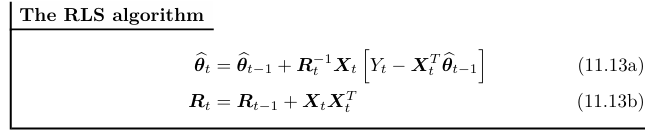

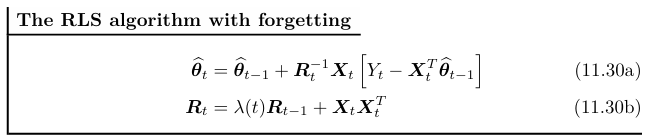

In [45]:
A = np.column_stack([np.ones(len(x_train)), x_train])

R0 = np.array(([0.1, 0],[0, 0.1]))
theta0 = np.array([0, 0])
t = 72
lamb07 = 0.7
lamb099 = 0.99
R_cal = []
theta_cal = []

In [33]:
def update(t, theta, R, x, y, lamb):
    R_cal = []
    theta_cal = []

    R_cal.append(R)
    theta_cal.append(theta)

    for i in range(0, t):
            R_cal.append(lamb * R_cal[-1] + np.outer(x[:,i], x[:,i]))
            theta_cal.append(theta_cal[-1] + np.linalg.inv(R_cal[-1]) @ x[:,i] * (y[i] - x[:,i].T @ theta_cal[-1] ))
    return R_cal, theta_cal 

In [55]:
R07, theta07 = update(t, theta0, R0, A.T, y_train, lamb07)

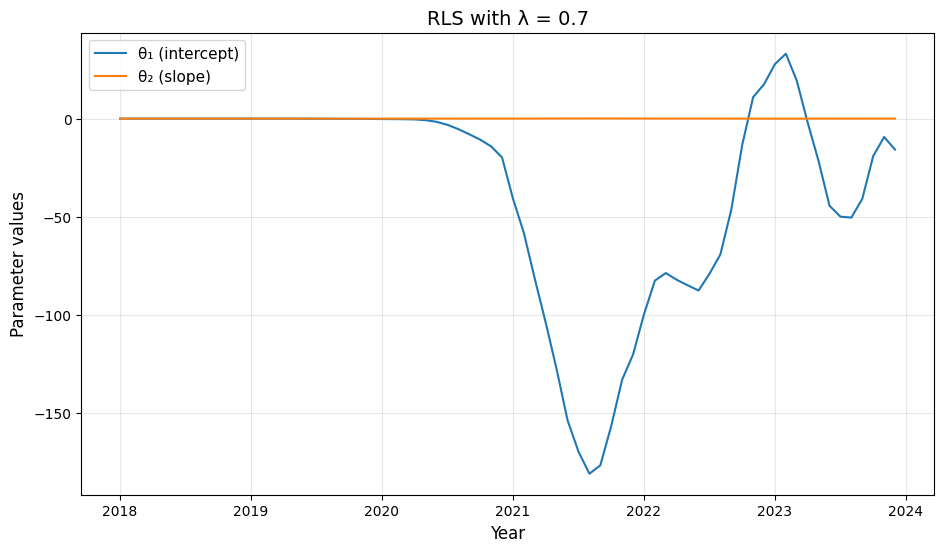

In [74]:
plt.figure(figsize=(11,6))
plt.plot(x_train, theta07[1:])
plt.xlabel('Year', fontsize=12)
plt.ylabel('Parameter values', fontsize=12)
plt.title('RLS with λ = 0.7', fontsize=14)
plt.legend(['θ₁ (intercept)', 'θ₂ (slope)'], fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

In [75]:
R099, theta099 = update(t, theta0, R0, A.T, y_train, lamb099)

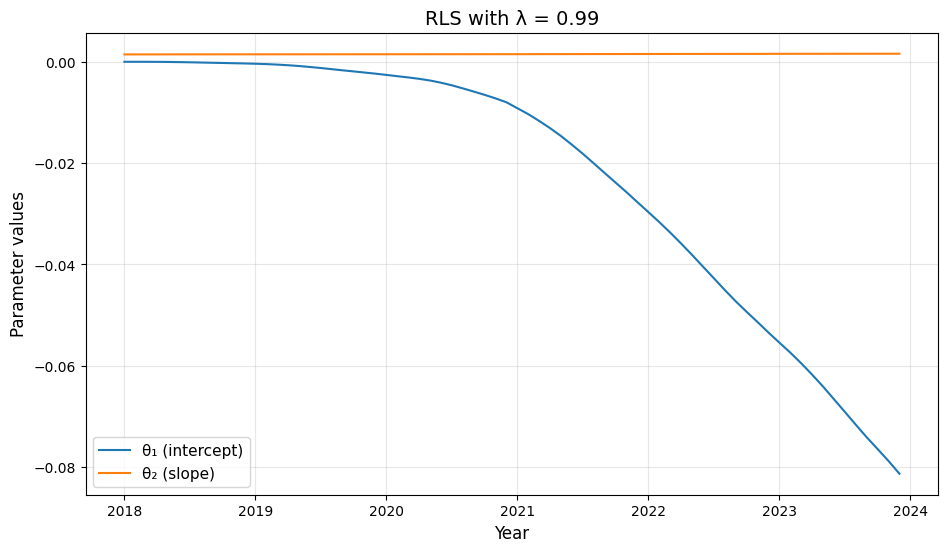

In [72]:
plt.figure(figsize=(11,6))
plt.plot(x_train, theta099[1:])
plt.xlabel('Year', fontsize=12)
plt.ylabel('Parameter values', fontsize=12)
plt.title('RLS with λ = 0.99', fontsize=14)
plt.legend(['θ₁ (intercept)', 'θ₂ (slope)'], fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

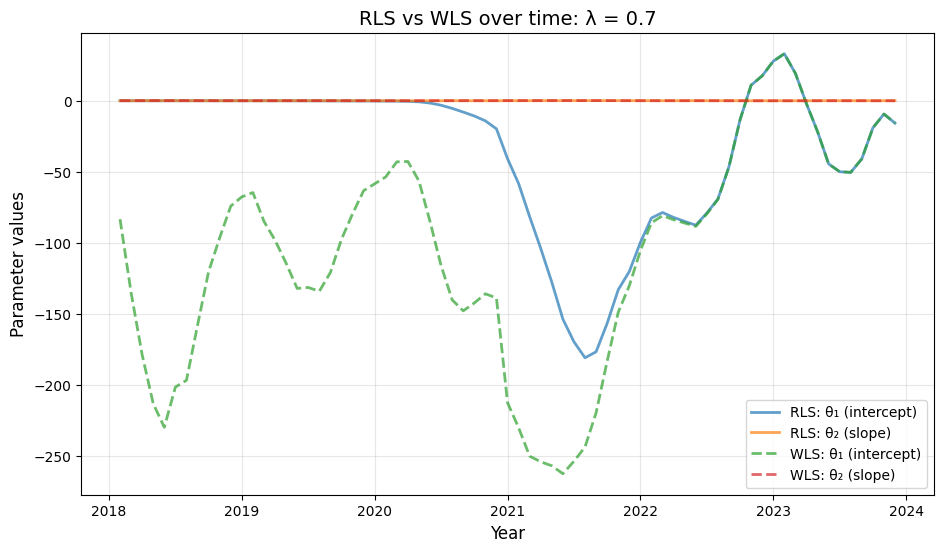

In [122]:

def calculate_WLS_at_t(t, lamb):
    lambda_weights = lamb ** np.arange(t-1, -1, -1)
    W = np.diag(lambda_weights)
    
    X = np.column_stack([np.ones(t), x_train.iloc[:t]])
    y = y_train.iloc[:t].to_numpy().reshape(-1, 1)
    
    # WLS solution is theta = (X^T W X)^(-1) X^T W y
    F_t_WLS = X.T @ W @ X
    h_t_WLS = X.T @ W @ y
    theta_wls = np.linalg.inv(F_t_WLS) @ h_t_WLS
    
    return theta_wls.flatten()

# for lambda = 0.7
N = len(y_train)
theta_wls_07_over_time = []

for t in range(2, N + 1):
    theta_t = calculate_WLS_at_t(t, lamb07)
    theta_wls_07_over_time.append(theta_t)

theta_wls_07_over_time = np.array(theta_wls_07_over_time)

plt.figure(figsize=(11, 6))

theta07_array = np.array(theta07[2:])  

plt.plot(x_train.iloc[1:], theta07_array[:, 0], label='RLS: θ₁ (intercept)', linestyle='-', linewidth=2, alpha=0.7)
plt.plot(x_train.iloc[1:], theta07_array[:, 1], label='RLS: θ₂ (slope)', linestyle='-', linewidth=2, alpha=0.7)


plt.plot(x_train.iloc[1:], theta_wls_07_over_time[:, 0], label='WLS: θ₁ (intercept)', 
         linestyle='--', linewidth=2, alpha=0.7)
plt.plot(x_train.iloc[1:], theta_wls_07_over_time[:, 1], label='WLS: θ₂ (slope)', 
         linestyle='--', linewidth=2, alpha=0.7)

plt.xlabel('Year', fontsize=12)
plt.ylabel('Parameter values', fontsize=12)
plt.title(f'RLS vs WLS over time: λ = {lamb07}', fontsize=14)
plt.legend(fontsize=10, loc='best')
plt.grid(True, alpha=0.3)
plt.show()

#### 5.5 One-step predictions

In [129]:
# Lambda = 0.7
y_pred_07 = []
for t in range(4, len(y_train)-1):
    theta = theta07[t]    
    x_t_plus_1 = np.array([1, x_train.iloc[t+1]])  # regressor at t+1
    y_hat = x_t_plus_1 @ theta   
    y_pred_07.append(y_hat)

# Lambda = 0.9
y_pred_099 = []
for t in range(4, len(y_train)-1):
    theta = theta099[t]    
    x_t_plus_1 = np.array([1, x_train.iloc[t+1]])  # regressor at t+1
    y_hat = x_t_plus_1 @ theta   
    y_pred_099.append(y_hat)

# estimated values:
y_pred_07 = np.array(y_pred_07)
y_pred_099 = np.array(y_pred_099)
# actual values - values from t = 5 og fremad
y_true = y_train.iloc[5:].values

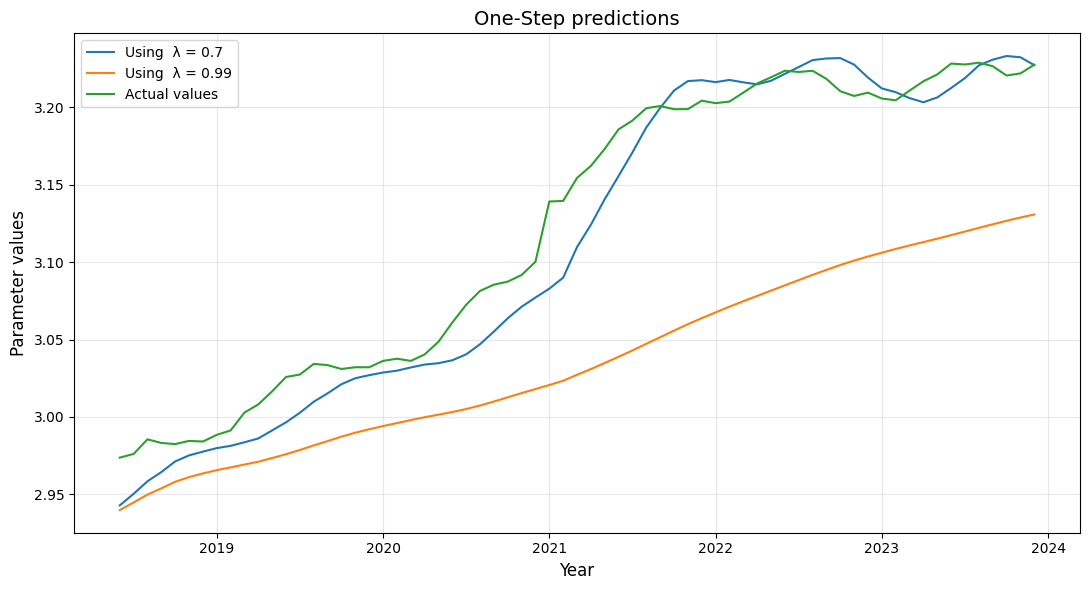

In [134]:
plt.figure(figsize=(11,6))

plt.plot(x_train[5:], y_pred_07, label='Using  λ = 0.7')
plt.plot(x_train[5:], y_pred_099, label='Using  λ = 0.99')
plt.plot(x_train[5:], y_true, label='Actual values')

plt.title('One-Step predictions', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Parameter values', fontsize=12)

plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

In [130]:
pred_error_07 =  y_true - y_pred_07
pred_error_099 = y_true - y_pred_099

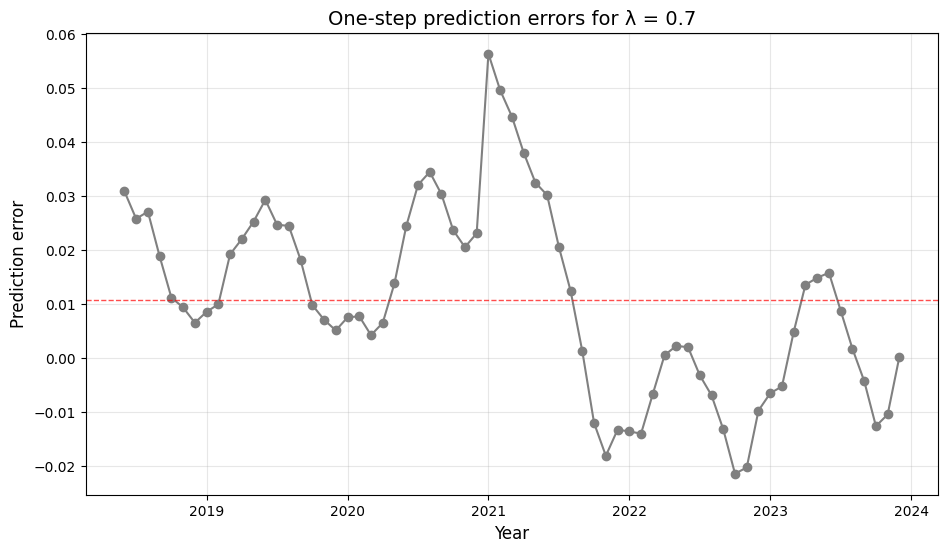

In [132]:
plt.figure(figsize=(11,6))
plt.plot(x_train[5:], pred_error_07, label='Prediction Error', linestyle='-', marker='o', color='grey')
plt.axhline(y=np.mean(pred_error_07), color='red', linestyle='--', linewidth=1,alpha=0.7, label=f'Mean = {np.mean(pred_error_07):.4f}')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Prediction error', fontsize=12)
plt.title(f'One-step prediction errors for λ = 0.7', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

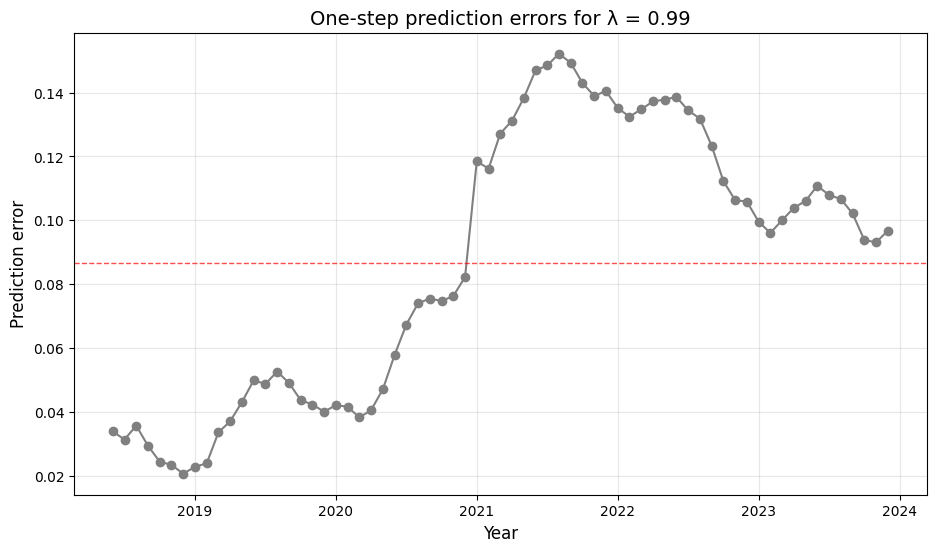

In [133]:
plt.figure(figsize=(11,6))
plt.plot(x_train[5:], pred_error_099, label='Prediction Error', linestyle='-', marker='o', color='grey')
plt.axhline(y=np.mean(pred_error_099), color='red', linestyle='--', linewidth=1,alpha=0.7, label=f'Mean = {np.mean(pred_error_099):.4f}')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Prediction error', fontsize=12)
plt.title(f'One-step prediction errors for λ = 0.99', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

### 5.6

In [163]:
theta0 = np.array([0,0])
# RMSE for multi-step predictions
def RLS_multi_step_RMSE(x, y, lambdas, k_max=12):
    N = len(y)
    rmse_results = {k: [] for k in range(1, k_max + 1)}
    
    # Design matrix som tidligere
    A = np.column_stack([np.ones(len(x)), x])
    
    for l in lambdas:
        R_list, theta_list = update(N, theta0, R0, A.T, y, l) # I update funktionen er det kun theta vi er intereseret i
        
        for k in range(1, k_max + 1):
            squared_errors = []
            
            # Predictions are calculated using theta_{t+k}
            for t in range(k, N):
                theta_t = theta_list[t-k] 
                x_t = A[t,:]
                y_pred = x_t @ theta_t # prediction for y_t using theta_{t-k}
                y_true = y[t]
                error = y_pred - y_true  # error / residuals - y er de rigtige værdier
                squared_errors.append(error**2) # I RMSE bruges squared errors
            
            # RMSE for k
            rmse = np.sqrt(np.sum(squared_errors) / (N - k))
            rmse_results[k].append(rmse)
    
    return rmse_results

In [167]:
# Lambda fra 0.5 til 0.99 er brugt (0.5 til 1.0 med 0.01 step imellem)
lambda_values = np.arange(0.5, 1.0, 0.01)
horizons = list(range(1, 13)) # værdier for k

# RMSE for værdierne
rmse_results = RLS_multi_step_RMSE(x_train, y_train, lambda_values, k_max=12)

for k in horizons:
    rmse_results[k] = np.array(rmse_results[k])


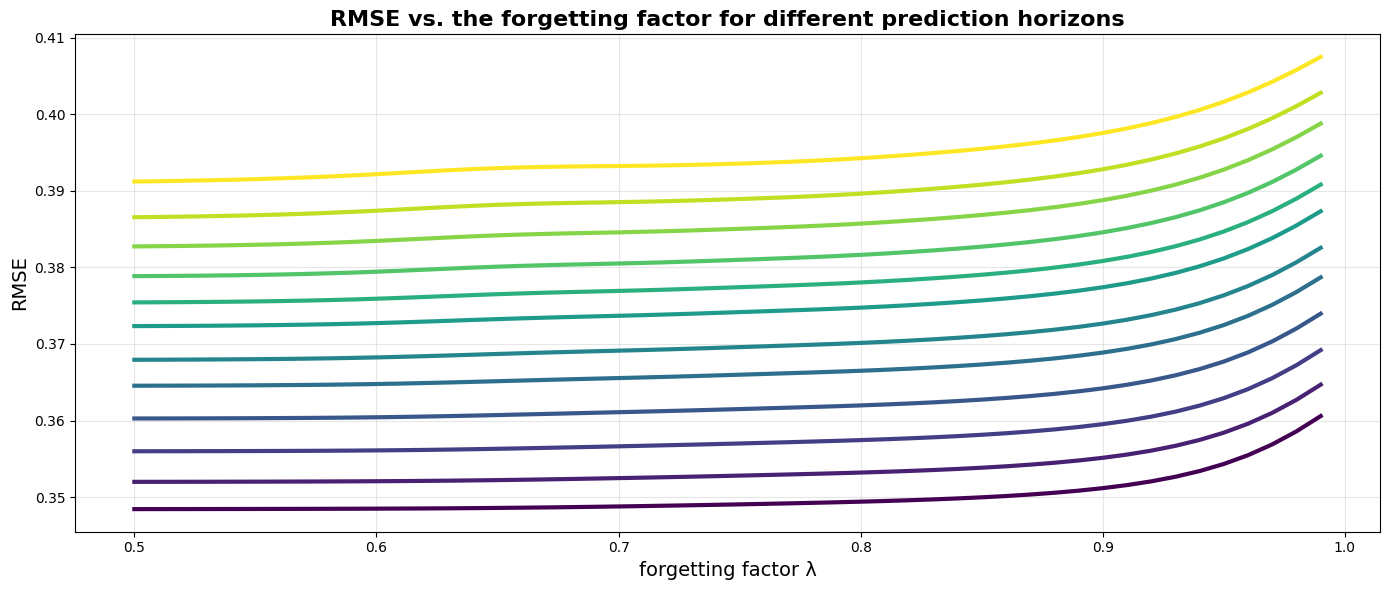

In [168]:
# Plot of RMSE for hver lambda værdi for de forskelige horizons
# Det bliver spændende...
plt.figure(figsize=(14, 6))

# COlormap for hver horizon
colors = plt.cm.viridis(np.linspace(0, 1, len(horizons)))

for i, k in enumerate(horizons):
    plt.plot(lambda_values, rmse_results[k], label=f'k={k}', color=colors[i], linewidth=3)

plt.xlabel('forgetting factor λ', fontsize = 14)
plt.ylabel('RMSE', fontsize = 14)
plt.title('RMSE vs. the forgetting factor for different prediction horizons', fontsize = 16, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5.7 Test Set Predictions

In [180]:
lambda_05 = 0.5

A_train = np.column_stack([np.ones(len(x_train)), x_train])

R_list, theta_list = update(len(y_train), theta0, R0, A_train.T, y_train, lambda_05)

theta_final = theta_list[-1]  # finder den sidste værdi når man bruger -1

In [183]:
# Predictions on the test dataset:
A_test = np.column_stack([np.ones(len(x_test)), x_test])

y_rls_test = A_test @ theta_final

In [197]:
k_max = 12
forecast_fan = np.full((len(y_test), k_max), np.nan)

# start fra træningsresultatet
theta = theta_list[-1].copy()
R = R_list[-1].copy()

for t in range(len(y_test)):
    # forecasts fra tid t
    for k in range(1, k_max+1):
        if t + k < len(y_test):
            forecast_fan[t, k-1] = A_test[t+k, :] @ theta  # y_{t+k|t}

    # opdater med observation ved tid t
    x_t = A_test[t, :]
    y_t = y_test.iloc[t]  

    R = lambda_05 * R + np.outer(x_t, x_t)
    theta = theta + np.linalg.inv(R) @ x_t * (y_t - x_t @ theta)

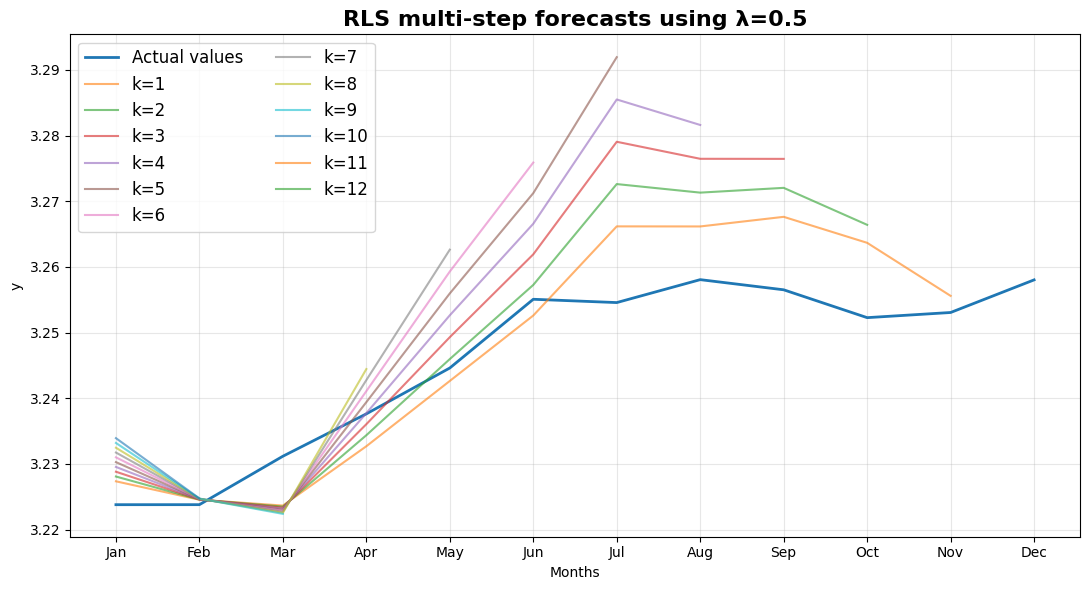

In [202]:
months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

plt.figure(figsize=(11,6))
plt.plot(x_test, y_test, label="Actual values", linewidth=2)

for k in range(1, 13):
    plt.plot(x_test, forecast_fan[:, k-1], label=f'k={k}', alpha=0.6)

plt.title(f'RLS multi-step forecasts using λ=0.5', fontsize=16, fontweight='bold')
plt.xlabel("Months"); plt.ylabel("y")
plt.xticks(x_test, months)
plt.grid(True, alpha=0.3)
plt.legend(ncol=2, fontsize=12)
plt.tight_layout()
plt.show()